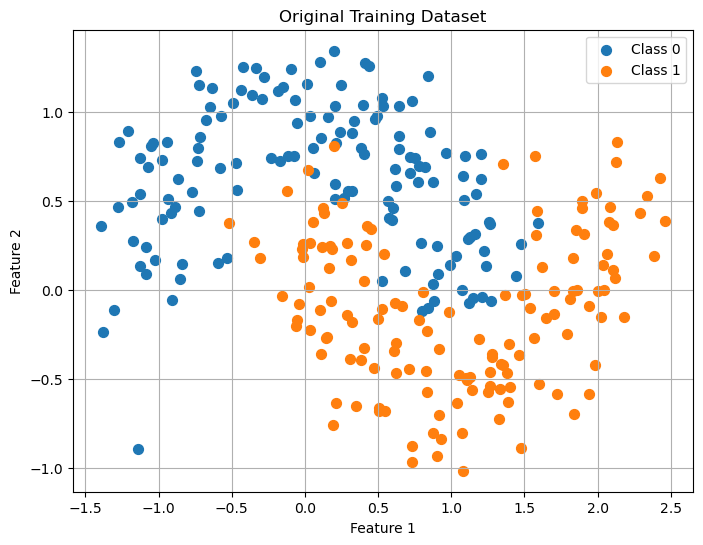

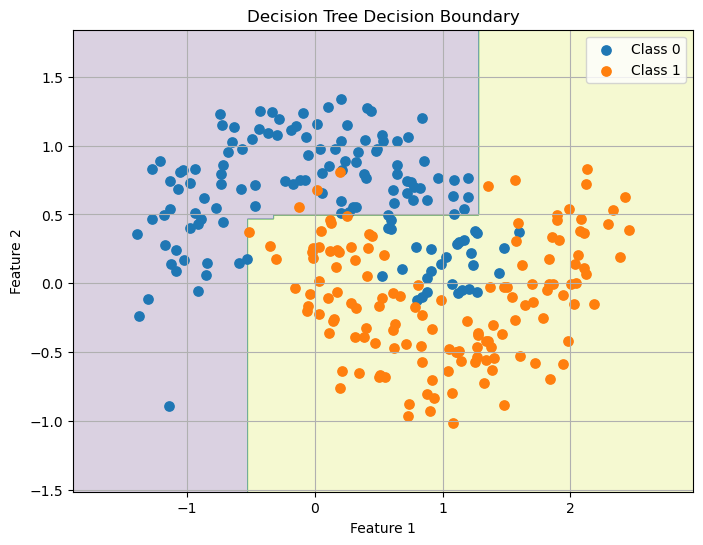

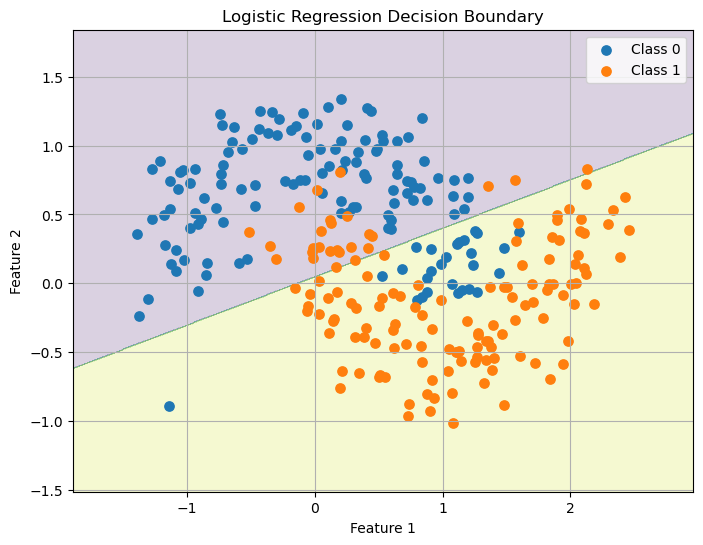

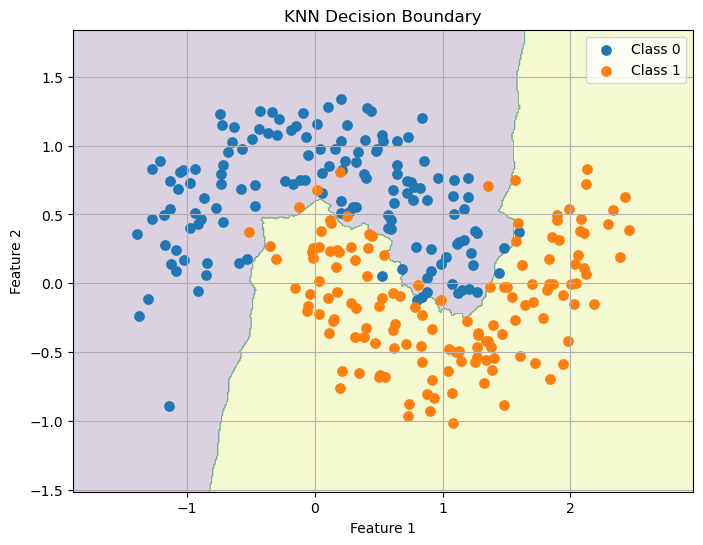

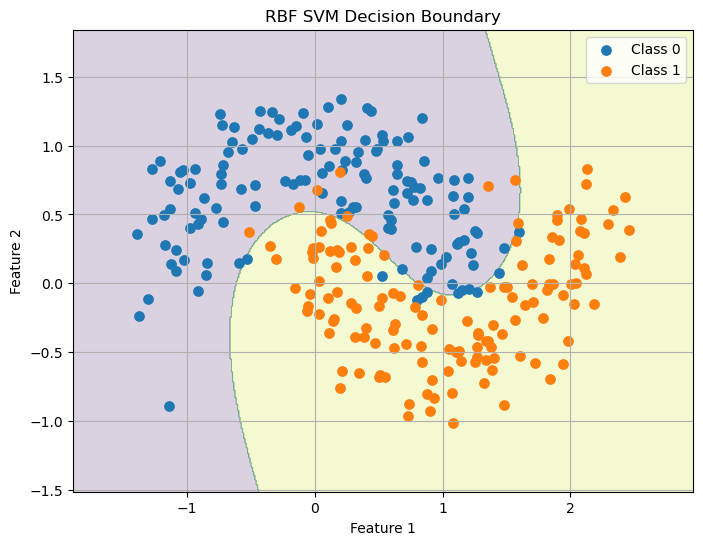

Decision Tree Accuracy = 91.67 %
Logistic Regression Accuracy = 89.17 %
KNN Accuracy = 90.0 %
RBF SVM Accuracy = 93.33 %

Hard Voting Accuracy: 94.17 %


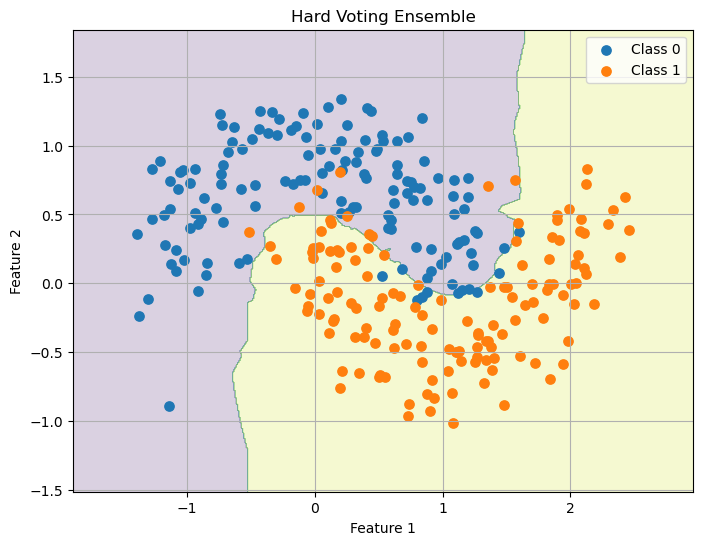


Soft Voting Accuracy: 94.17 %


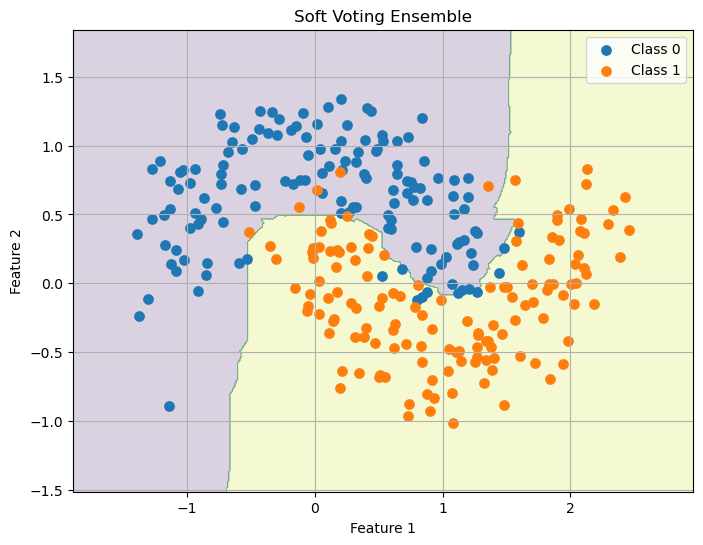


PROBABILITY COMPARISON FOR ONE SAMPLE
Decision Tree → Class 0: 0.475 | Class 1: 0.525
Logistic Regression → Class 0: 0.096 | Class 1: 0.904
KNN → Class 0: 0.0 | Class 1: 1.0
RBF SVM → Class 0: 0.008 | Class 1: 0.992


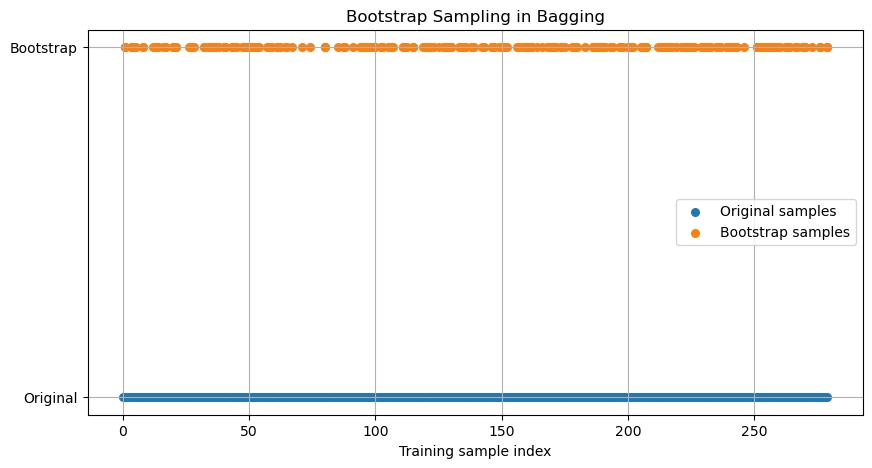


Bagging Accuracy: 94.17 %


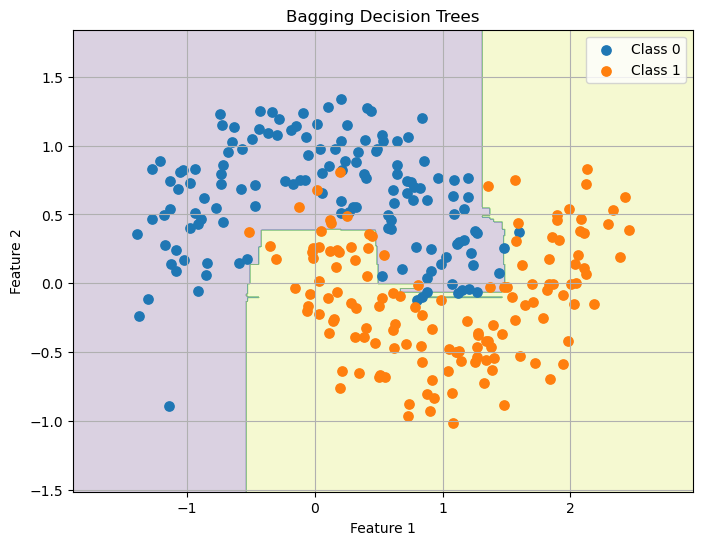


Random Forest Accuracy: 93.33 %


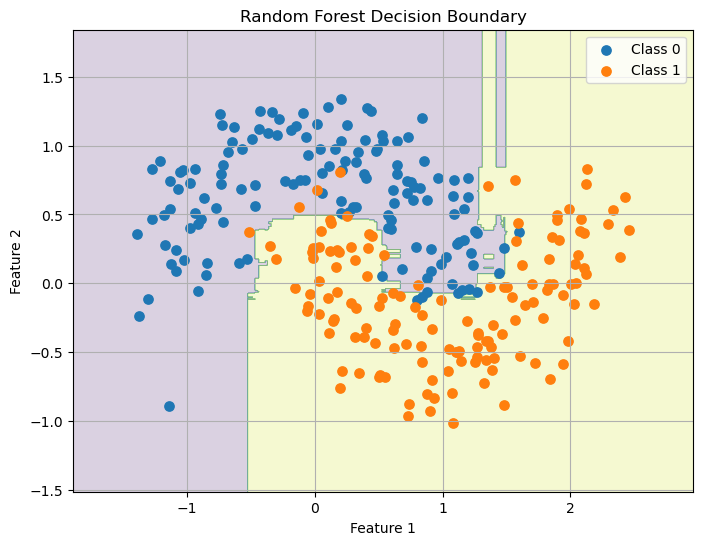

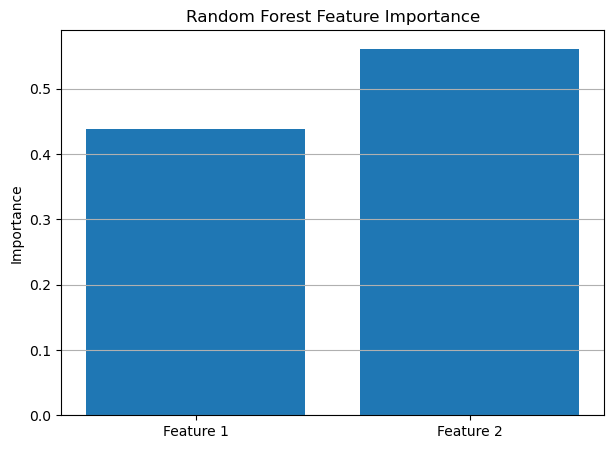

C:\Users\palan\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



AdaBoost Accuracy: 90.83 %


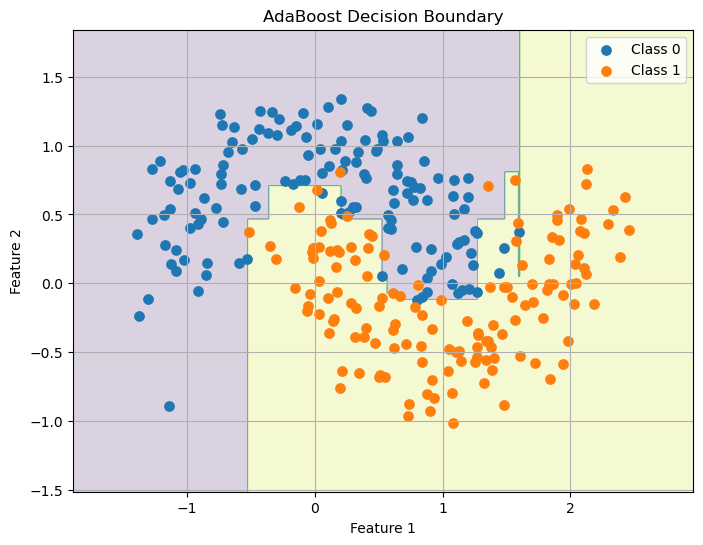

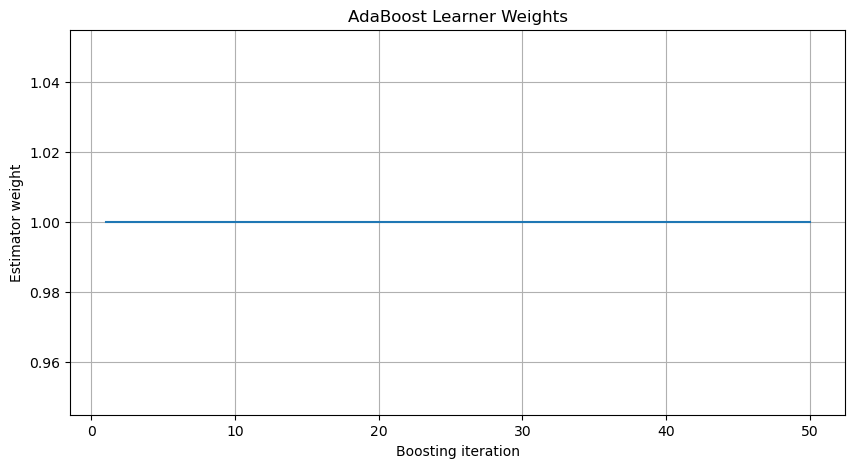


Gradient Boosting Accuracy: 93.33 %


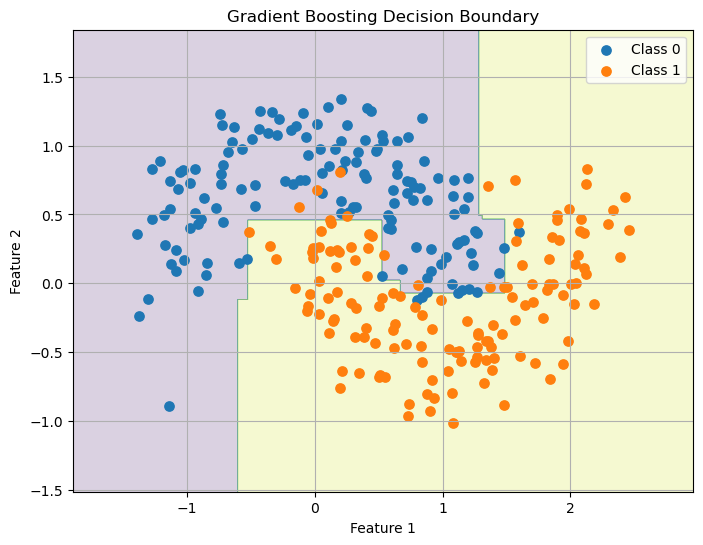

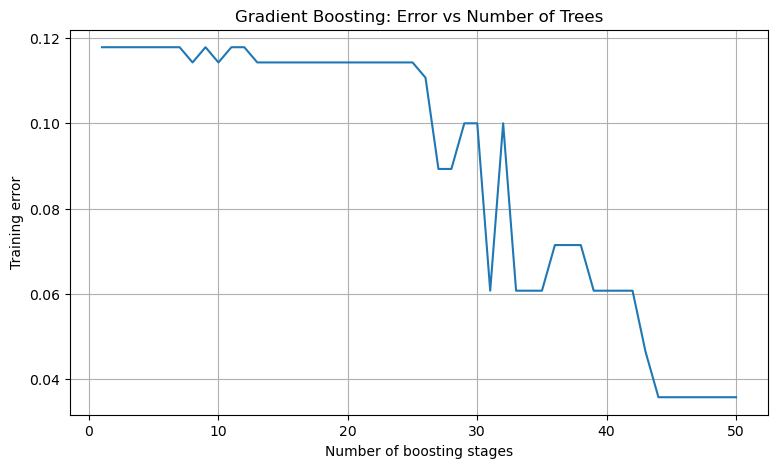


Stacking Accuracy: 92.5 %


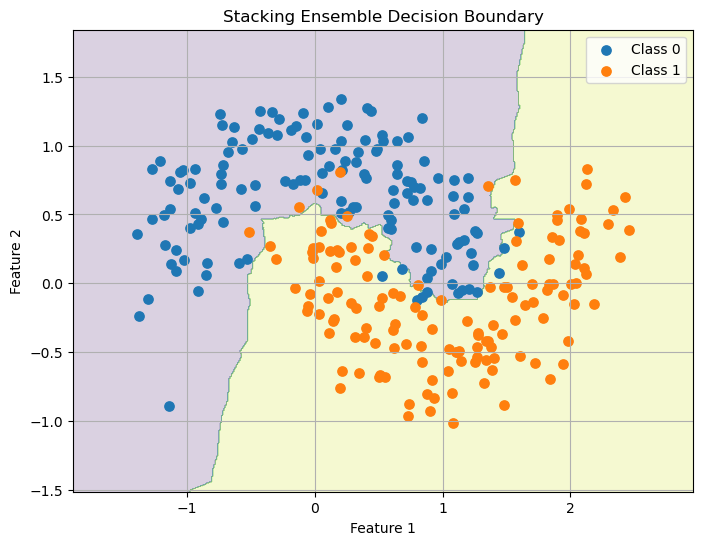

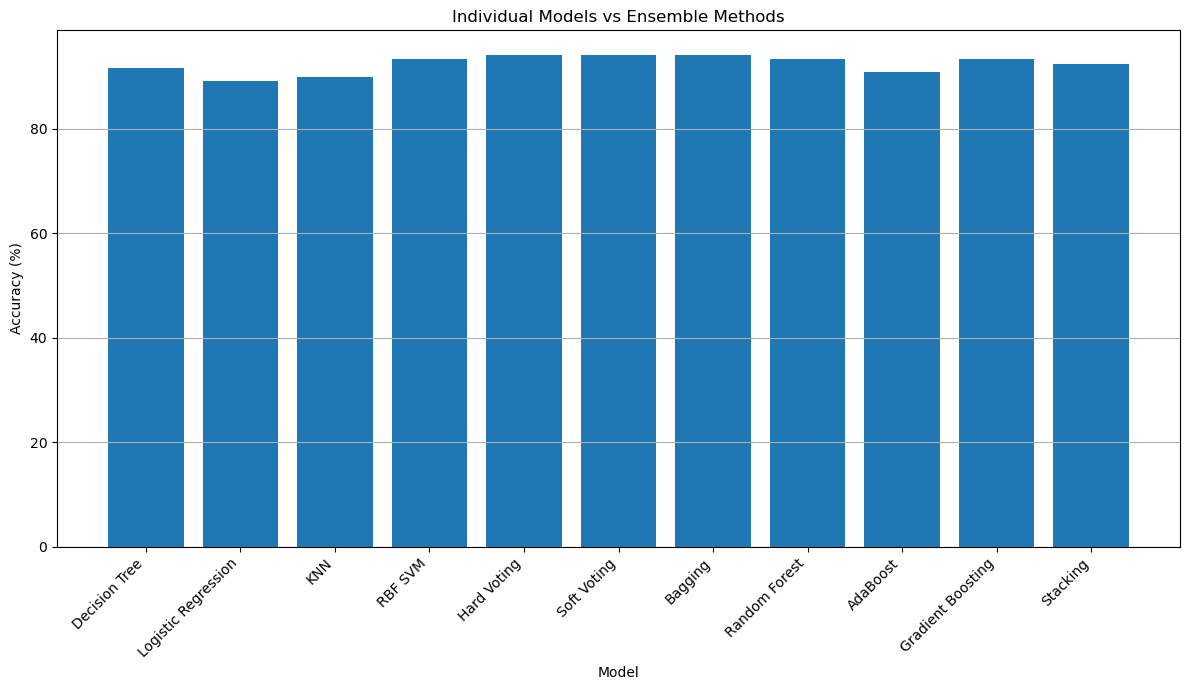

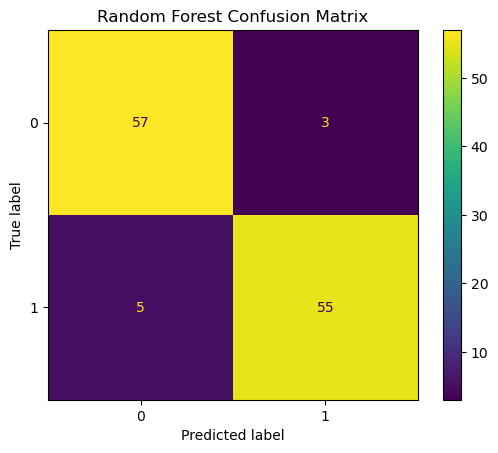

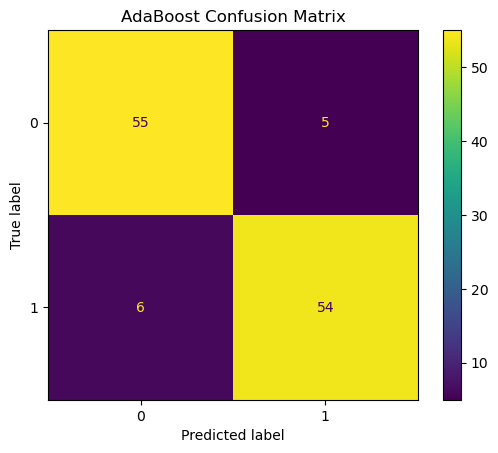

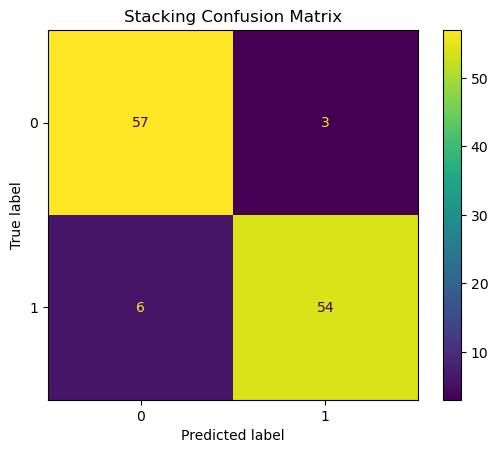


DETAILED PERFORMANCE

 Decision Tree
Accuracy : 0.917
Precision: 0.891
Recall   : 0.95
F1 Score : 0.919

 Hard Voting
Accuracy : 0.942
Precision: 0.949
Recall   : 0.933
F1 Score : 0.941

 Soft Voting
Accuracy : 0.942
Precision: 0.949
Recall   : 0.933
F1 Score : 0.941

 Bagging
Accuracy : 0.942
Precision: 0.965
Recall   : 0.917
F1 Score : 0.94

 Random Forest
Accuracy : 0.933
Precision: 0.948
Recall   : 0.917
F1 Score : 0.932

 AdaBoost
Accuracy : 0.908
Precision: 0.915
Recall   : 0.9
F1 Score : 0.908

 Gradient Boosting
Accuracy : 0.933
Precision: 0.948
Recall   : 0.917
F1 Score : 0.932

 Stacking
Accuracy : 0.925
Precision: 0.947
Recall   : 0.9
F1 Score : 0.923


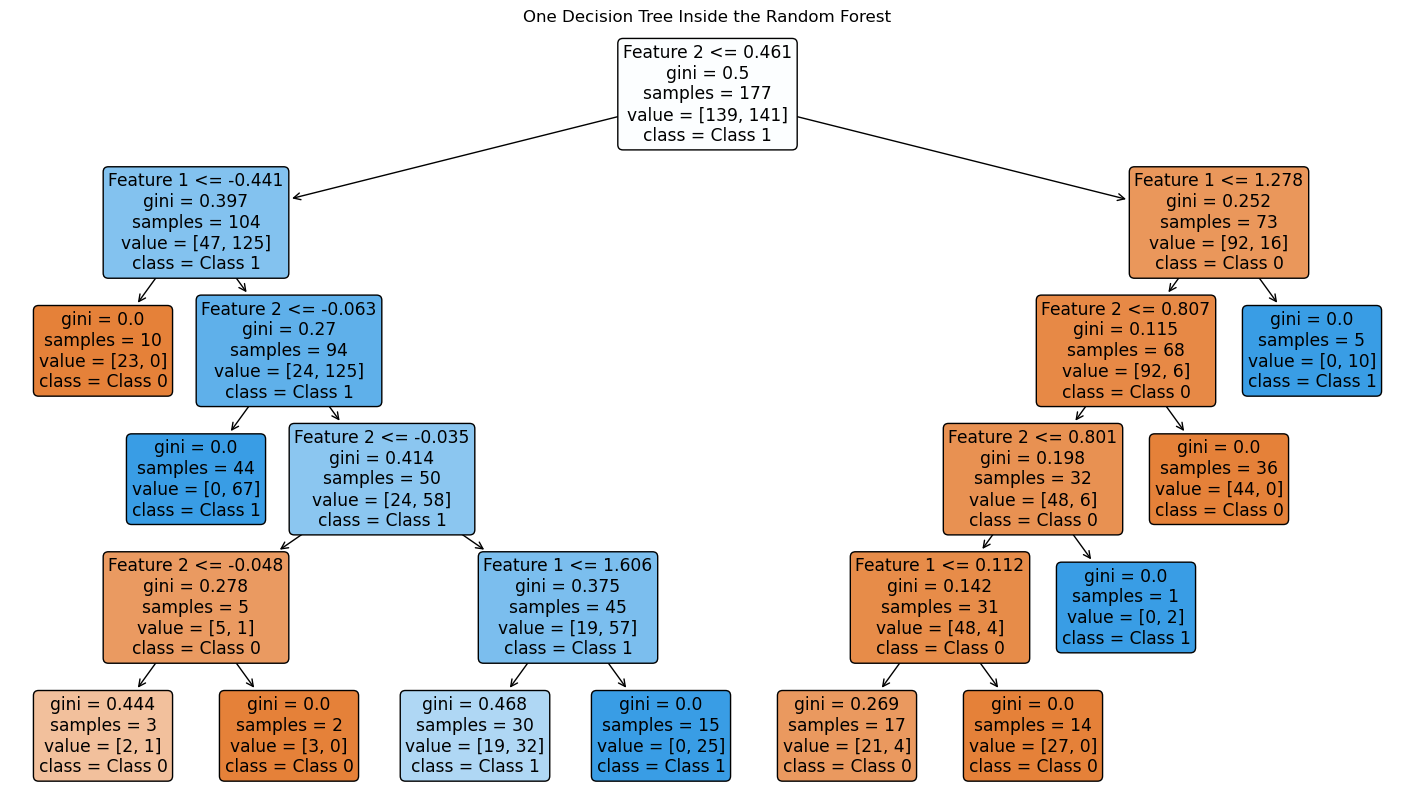

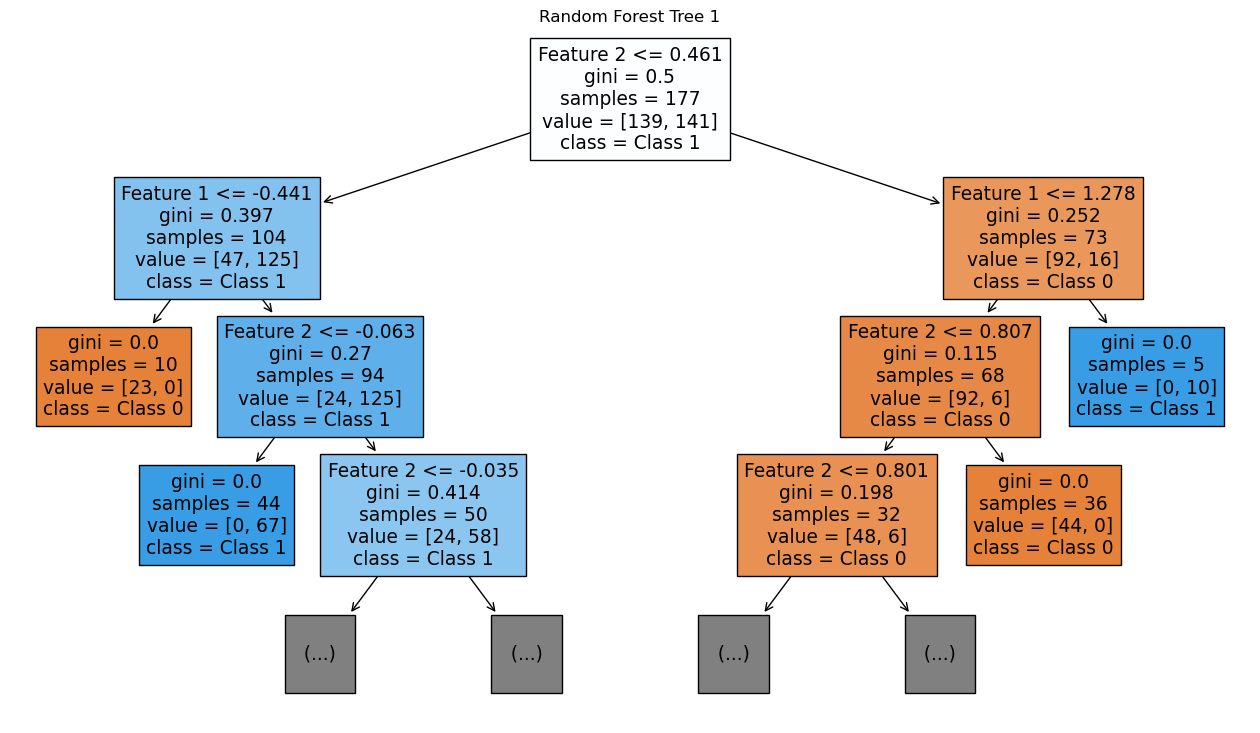

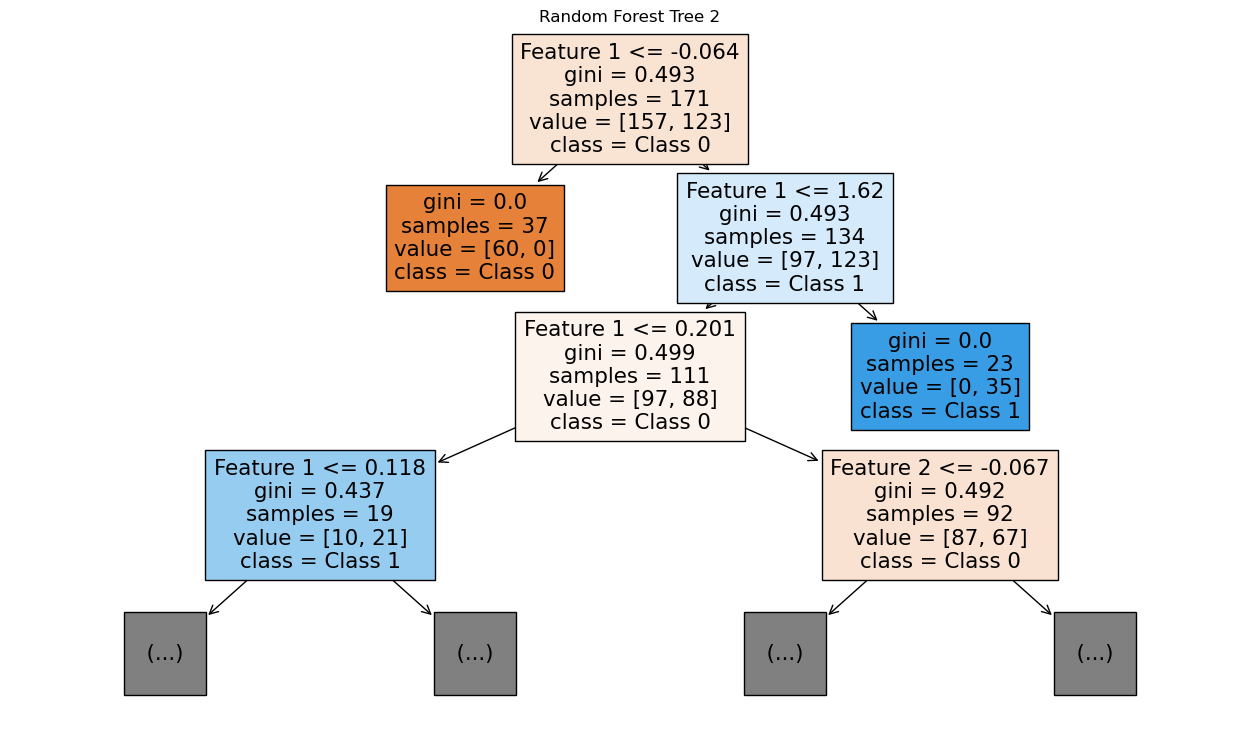

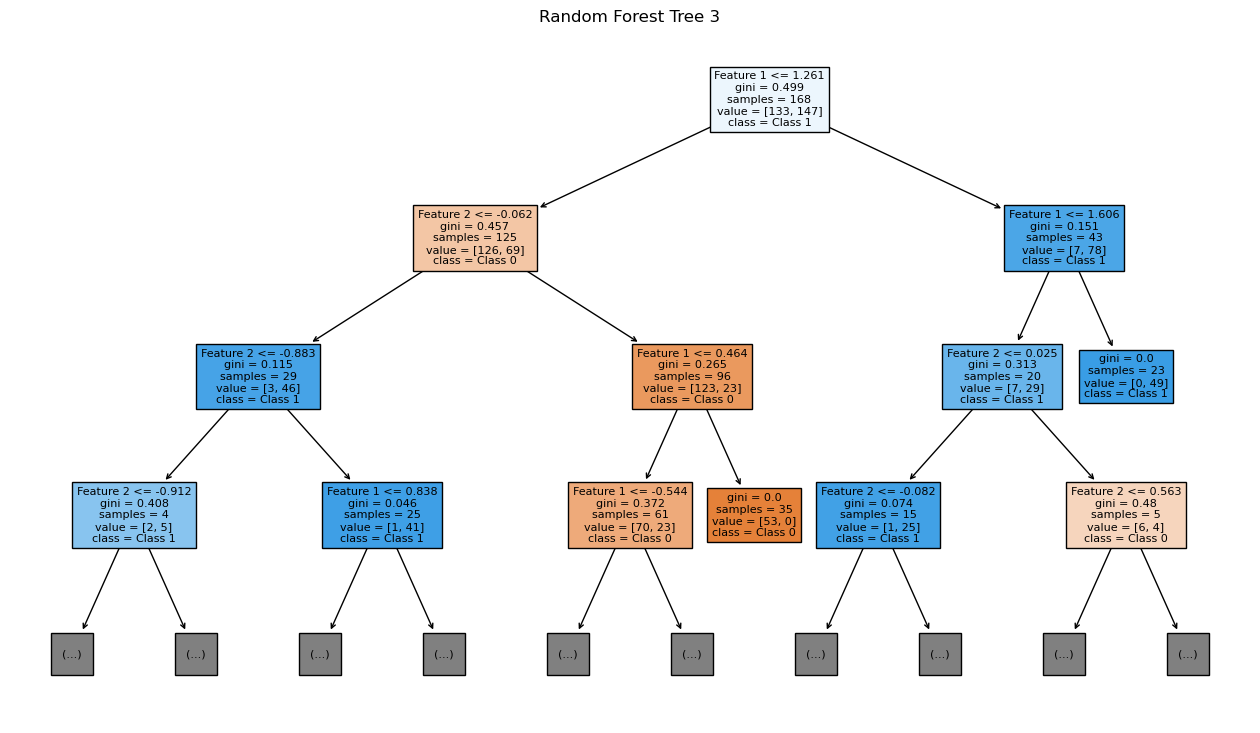


ENSEMBLE LEARNING SUMMARY

1. HARD VOTING
   Each model votes for a class.
   Final class = majority vote.

2. SOFT VOTING
   Each model provides probabilities.
   Final prediction = highest average probability.

3. BAGGING
   Train models independently on bootstrap samples.
   Combine their predictions.

4. RANDOM FOREST
   Bagging + random feature selection + decision trees.

5. ADABOOST
   Train weak learners sequentially.
   Give more attention to difficult samples.

6. GRADIENT BOOSTING
   Sequentially build learners that reduce previous
   prediction errors using gradient-based optimization.

7. STACKING
   Base models generate predictions.
   A meta-model learns how to combine them.

8. MODEL DIVERSITY
   Ensemble methods work particularly well when
   individual models make different errors.

9. FINAL IDEA

   Multiple imperfect models
              |
              v
       Combine predictions
              |
              v
       Better generalization
   


In [3]:
# ============================================================
# ENSEMBLE LEARNING
# ============================================================
#
# This program demonstrates the major concepts of
# ensemble learning using a 2-D classification problem.
#
# Topics covered:
#
# 1. Single Decision Tree
# 2. Hard Voting
# 3. Soft Voting
# 4. Bagging
# 5. Random Forest
# 6. AdaBoost
# 7. Gradient Boosting
# 8. Stacking
# 9. Model diversity
# 10. Decision boundaries
# 11. Individual predictions
# 12. Ensemble predictions
# 13. Bootstrap samples
# 14. Boosting sample weights
# 15. Performance comparison
# 16. Confusion matrices
#
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np

import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

from sklearn.datasets import make_moons

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.ensemble import (
    VotingClassifier,
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 2. CREATE A NONLINEAR DATASET
# ============================================================
#
# make_moons creates two interlocking classes.
#
# This dataset is useful because:
#
# - A simple model may underfit.
# - Different models produce different boundaries.
# - Combining models can improve performance.
#
# ============================================================

X, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=42
)


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. VISUALIZE ORIGINAL DATASET
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    label="Class 0",
    s=50
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Class 1",
    s=50
)

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title(
    "Original Training Dataset"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# PART A
# SINGLE BASE LEARNERS
# ============================================================


# ============================================================
# 5. CREATE DIFFERENT BASE LEARNERS
# ============================================================
#
# We deliberately choose different algorithms.
#
# Each algorithm has a different inductive bias.
#
# Decision Tree
# Logistic Regression
# KNN
# SVM
#
# Their errors will not necessarily be identical.
#
# This diversity is important for ensemble learning.
#
# ============================================================


tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)


logistic_model = LogisticRegression(
    random_state=42
)


knn_model = KNeighborsClassifier(
    n_neighbors=7
)


svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)


# ============================================================
# 6. STORE BASE MODELS
# ============================================================

base_models = {

    "Decision Tree": tree_model,

    "Logistic Regression": logistic_model,

    "KNN": knn_model,

    "RBF SVM": svm_model

}


# ============================================================
# 7. FUNCTION TO PLOT DECISION BOUNDARY
# ============================================================

def plot_decision_boundary(
    model,
    X,
    y,
    title
):

    # --------------------------------------------------------
    # Determine plotting limits
    # --------------------------------------------------------

    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5


    # --------------------------------------------------------
    # Create a 2-D grid
    # --------------------------------------------------------

    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            500
        ),
        np.linspace(
            y_min,
            y_max,
            500
        )
    )


    # Convert grid into feature matrix
    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]


    # --------------------------------------------------------
    # Predict class for every grid point
    # --------------------------------------------------------

    predictions = model.predict(
        grid
    )


    predictions = predictions.reshape(
        xx.shape
    )


    # --------------------------------------------------------
    # Plot decision regions
    # --------------------------------------------------------

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.20
    )


    # --------------------------------------------------------
    # Plot training samples
    # --------------------------------------------------------

    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0",
        s=45
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1",
        s=45
    )


    plt.xlabel("Feature 1")

    plt.ylabel("Feature 2")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.show()


# ============================================================
# 8. TRAIN AND VISUALIZE BASE MODELS
# ============================================================

for name, model in base_models.items():

    # Train model
    model.fit(
        X_train,
        y_train
    )

    # Visualize decision boundary
    plot_decision_boundary(
        model,
        X_train,
        y_train,
        name + " Decision Boundary"
    )


# ============================================================
# PART B
# PERFORMANCE OF INDIVIDUAL MODELS
# ============================================================


# ============================================================
# 9. CALCULATE PERFORMANCE
# ============================================================

individual_accuracy = {}


for name, model in base_models.items():

    predictions = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    individual_accuracy[name] = accuracy


    print(
        name,
        "Accuracy =",
        round(accuracy * 100, 2),
        "%"
    )


# ============================================================
# PART C
# HARD VOTING
# ============================================================
#
# HARD VOTING:
#
# Each model predicts a class.
#
# Example:
#
# Model 1 → Class 0
# Model 2 → Class 1
# Model 3 → Class 1
# Model 4 → Class 1
#
# Final prediction:
#
#       Class 1
#
# because it received the majority of votes.
#
# ============================================================


# ============================================================
# 10. CREATE HARD VOTING CLASSIFIER
# ============================================================

hard_voting = VotingClassifier(

    estimators=[
        ("tree", DecisionTreeClassifier(
            max_depth=4,
            random_state=42
        )),

        ("logistic", LogisticRegression(
            random_state=42
        )),

        ("knn", KNeighborsClassifier(
            n_neighbors=7
        )),

        ("svm", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ],

    voting="hard"
)


# ============================================================
# 11. TRAIN HARD VOTING MODEL
# ============================================================

hard_voting.fit(
    X_train,
    y_train
)


# ============================================================
# 12. PREDICT USING HARD VOTING
# ============================================================

hard_predictions = hard_voting.predict(
    X_test
)


hard_accuracy = accuracy_score(
    y_test,
    hard_predictions
)


print(
    "\nHard Voting Accuracy:",
    round(hard_accuracy * 100, 2),
    "%"
)


# ============================================================
# 13. VISUALIZE HARD VOTING
# ============================================================

plot_decision_boundary(
    hard_voting,
    X_train,
    y_train,
    "Hard Voting Ensemble"
)


# ============================================================
# PART D
# SOFT VOTING
# ============================================================
#
# SOFT VOTING uses predicted probabilities.
#
# Example:
#
# Model 1:
#   P(Class 0) = 0.70
#   P(Class 1) = 0.30
#
# Model 2:
#   P(Class 0) = 0.40
#   P(Class 1) = 0.60
#
# Model 3:
#   P(Class 0) = 0.20
#   P(Class 1) = 0.80
#
# Average probabilities are calculated.
#
# Class with highest average probability wins.
#
# ============================================================


# ============================================================
# 14. CREATE SOFT VOTING CLASSIFIER
# ============================================================

soft_voting = VotingClassifier(

    estimators=[
        ("tree", DecisionTreeClassifier(
            max_depth=4,
            random_state=42
        )),

        ("logistic", LogisticRegression(
            random_state=42
        )),

        ("knn", KNeighborsClassifier(
            n_neighbors=7
        )),

        ("svm", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ],

    voting="soft"
)


# ============================================================
# 15. TRAIN SOFT VOTING
# ============================================================

soft_voting.fit(
    X_train,
    y_train
)


# ============================================================
# 16. PREDICT
# ============================================================

soft_predictions = soft_voting.predict(
    X_test
)


soft_accuracy = accuracy_score(
    y_test,
    soft_predictions
)


print(
    "\nSoft Voting Accuracy:",
    round(soft_accuracy * 100, 2),
    "%"
)


# ============================================================
# 17. VISUALIZE SOFT VOTING
# ============================================================

plot_decision_boundary(
    soft_voting,
    X_train,
    y_train,
    "Soft Voting Ensemble"
)


# ============================================================
# PART E
# VISUALIZE MODEL PROBABILITIES
# ============================================================


# ============================================================
# 18. CHOOSE ONE TEST SAMPLE
# ============================================================

sample = X_test[0].reshape(
    1,
    -1
)


print(
    "\n=========================================="
)

print(
    "PROBABILITY COMPARISON FOR ONE SAMPLE"
)

print(
    "=========================================="
)


# ============================================================
# 19. DISPLAY PROBABILITY FROM EACH MODEL
# ============================================================

for name, model in base_models.items():

    probabilities = model.predict_proba(
        sample
    )[0]


    print(
        name,
        "→ Class 0:",
        round(probabilities[0], 3),
        "| Class 1:",
        round(probabilities[1], 3)
    )


# ============================================================
# PART F
# BAGGING
# ============================================================
#
# BAGGING = Bootstrap Aggregating
#
# Steps:
#
# 1. Generate bootstrap samples.
# 2. Train one model on each sample.
# 3. Combine predictions.
#
# ============================================================


# ============================================================
# 20. VISUALIZE BOOTSTRAP SAMPLING
# ============================================================

np.random.seed(42)


n_samples = len(X_train)

sample_indices = np.arange(
    n_samples
)


plt.figure(figsize=(10, 5))


# Original dataset
plt.scatter(
    sample_indices,
    np.zeros(n_samples),
    label="Original samples",
    s=30
)


# Bootstrap sample
bootstrap_indices = np.random.choice(
    n_samples,
    size=n_samples,
    replace=True
)


plt.scatter(
    bootstrap_indices,
    np.ones(n_samples),
    label="Bootstrap samples",
    s=30
)


plt.yticks(
    [0, 1],
    ["Original", "Bootstrap"]
)


plt.xlabel(
    "Training sample index"
)


plt.title(
    "Bootstrap Sampling in Bagging"
)


plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 21. CREATE BAGGING MODEL
# ============================================================

bagging_model = BaggingClassifier(

    estimator=DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),

    n_estimators=20,

    max_samples=0.8,

    bootstrap=True,

    random_state=42
)


# ============================================================
# 22. TRAIN BAGGING MODEL
# ============================================================

bagging_model.fit(
    X_train,
    y_train
)


# ============================================================
# 23. PREDICT BAGGING
# ============================================================

bagging_predictions = bagging_model.predict(
    X_test
)


bagging_accuracy = accuracy_score(
    y_test,
    bagging_predictions
)


print(
    "\nBagging Accuracy:",
    round(bagging_accuracy * 100, 2),
    "%"
)


# ============================================================
# 24. VISUALIZE BAGGING DECISION BOUNDARY
# ============================================================

plot_decision_boundary(
    bagging_model,
    X_train,
    y_train,
    "Bagging Decision Trees"
)


# ============================================================
# PART G
# RANDOM FOREST
# ============================================================
#
# Random Forest adds another source of randomness:
#
#       Random samples
#             +
#       Random features
#
# ============================================================


# ============================================================
# 25. CREATE RANDOM FOREST
# ============================================================

random_forest = RandomForestClassifier(

    n_estimators=50,

    max_depth=5,

    max_features="sqrt",

    bootstrap=True,

    random_state=42
)


# ============================================================
# 26. TRAIN RANDOM FOREST
# ============================================================

random_forest.fit(
    X_train,
    y_train
)


# ============================================================
# 27. PREDICT
# ============================================================

rf_predictions = random_forest.predict(
    X_test
)


rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)


print(
    "\nRandom Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)


# ============================================================
# 28. VISUALIZE RANDOM FOREST
# ============================================================

plot_decision_boundary(
    random_forest,
    X_train,
    y_train,
    "Random Forest Decision Boundary"
)


# ============================================================
# 29. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================
#
# Random Forest can estimate how important each feature is
# for making predictions.
#
# ============================================================

importance = random_forest.feature_importances_


plt.figure(figsize=(7, 5))


plt.bar(
    ["Feature 1", "Feature 2"],
    importance
)


plt.ylabel(
    "Importance"
)


plt.title(
    "Random Forest Feature Importance"
)


plt.grid(
    axis="y"
)


plt.show()


# ============================================================
# PART H
# ADABOOST
# ============================================================
#
# BOOSTING works sequentially.
#
# Instead of building independent trees, each new learner
# attempts to focus more on samples that previous learners
# handled poorly.
#
# ============================================================


# ============================================================
# 30. CREATE ADABOOST
# ============================================================

adaboost = AdaBoostClassifier(

    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),

    n_estimators=50,

    learning_rate=0.5,

    random_state=42
)


# ============================================================
# 31. TRAIN ADABOOST
# ============================================================

adaboost.fit(
    X_train,
    y_train
)


# ============================================================
# 32. PREDICT
# ============================================================

ada_predictions = adaboost.predict(
    X_test
)


ada_accuracy = accuracy_score(
    y_test,
    ada_predictions
)


print(
    "\nAdaBoost Accuracy:",
    round(ada_accuracy * 100, 2),
    "%"
)


# ============================================================
# 33. VISUALIZE ADABOOST
# ============================================================

plot_decision_boundary(
    adaboost,
    X_train,
    y_train,
    "AdaBoost Decision Boundary"
)


# ============================================================
# 34. VISUALIZE ADABOOST ESTIMATOR WEIGHTS
# ============================================================
#
# Every weak learner receives an importance weight.
#
# Larger weight:
#
#       More contribution to final prediction.
#
# ============================================================

plt.figure(figsize=(10, 5))


plt.plot(
    np.arange(
        1,
        len(adaboost.estimator_weights_) + 1
    ),
    adaboost.estimator_weights_
)


plt.xlabel(
    "Boosting iteration"
)


plt.ylabel(
    "Estimator weight"
)


plt.title(
    "AdaBoost Learner Weights"
)


plt.grid(True)

plt.show()


# ============================================================
# PART I
# GRADIENT BOOSTING
# ============================================================


# ============================================================
# 35. CREATE GRADIENT BOOSTING MODEL
# ============================================================

gradient_boosting = GradientBoostingClassifier(

    n_estimators=50,

    learning_rate=0.05,

    max_depth=2,

    random_state=42
)


# ============================================================
# 36. TRAIN
# ============================================================

gradient_boosting.fit(
    X_train,
    y_train
)


# ============================================================
# 37. PREDICT
# ============================================================

gb_predictions = gradient_boosting.predict(
    X_test
)


gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)


print(
    "\nGradient Boosting Accuracy:",
    round(gb_accuracy * 100, 2),
    "%"
)


# ============================================================
# 38. VISUALIZE GRADIENT BOOSTING
# ============================================================

plot_decision_boundary(
    gradient_boosting,
    X_train,
    y_train,
    "Gradient Boosting Decision Boundary"
)


# ============================================================
# 39. GRADIENT BOOSTING TRAINING ERROR
# ============================================================
#
# This shows how the ensemble improves as additional
# boosting stages are added.
#
# ============================================================

staged_errors = []


for predictions in gradient_boosting.staged_predict(
    X_train
):

    error = np.mean(
        predictions != y_train
    )

    staged_errors.append(
        error
    )


plt.figure(figsize=(9, 5))


plt.plot(
    np.arange(
        1,
        len(staged_errors) + 1
    ),
    staged_errors
)


plt.xlabel(
    "Number of boosting stages"
)


plt.ylabel(
    "Training error"
)


plt.title(
    "Gradient Boosting: Error vs Number of Trees"
)


plt.grid(True)

plt.show()


# ============================================================
# PART J
# STACKING
# ============================================================
#
# STACKING has two levels.
#
# LEVEL 1:
#
# Several base models make predictions.
#
# LEVEL 2:
#
# A meta-model learns how to combine those predictions.
#
# ============================================================


# ============================================================
# 40. DEFINE BASE MODELS
# ============================================================

stack_estimators = [

    (
        "tree",
        DecisionTreeClassifier(
            max_depth=4,
            random_state=42
        )
    ),

    (
        "logistic",
        LogisticRegression(
            random_state=42
        )
    ),

    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=7
        )
    )
]


# ============================================================
# 41. CREATE STACKING CLASSIFIER
# ============================================================

stacking_model = StackingClassifier(

    estimators=stack_estimators,

    final_estimator=LogisticRegression(),

    cv=5
)


# ============================================================
# 42. TRAIN STACKING
# ============================================================

stacking_model.fit(
    X_train,
    y_train
)


# ============================================================
# 43. PREDICT
# ============================================================

stack_predictions = stacking_model.predict(
    X_test
)


stack_accuracy = accuracy_score(
    y_test,
    stack_predictions
)


print(
    "\nStacking Accuracy:",
    round(stack_accuracy * 100, 2),
    "%"
)


# ============================================================
# 44. VISUALIZE STACKING
# ============================================================

plot_decision_boundary(
    stacking_model,
    X_train,
    y_train,
    "Stacking Ensemble Decision Boundary"
)


# ============================================================
# PART K
# COMPARE ALL ENSEMBLE METHODS
# ============================================================


# ============================================================
# 45. COLLECT ACCURACIES
# ============================================================

model_names = [

    "Decision Tree",

    "Logistic Regression",

    "KNN",

    "RBF SVM",

    "Hard Voting",

    "Soft Voting",

    "Bagging",

    "Random Forest",

    "AdaBoost",

    "Gradient Boosting",

    "Stacking"
]


model_accuracies = [

    individual_accuracy["Decision Tree"],

    individual_accuracy["Logistic Regression"],

    individual_accuracy["KNN"],

    individual_accuracy["RBF SVM"],

    hard_accuracy,

    soft_accuracy,

    bagging_accuracy,

    rf_accuracy,

    ada_accuracy,

    gb_accuracy,

    stack_accuracy
]


# ============================================================
# 46. BAR CHART
# ============================================================

plt.figure(figsize=(12, 7))


plt.bar(
    model_names,
    np.array(model_accuracies) * 100
)


plt.ylabel(
    "Accuracy (%)"
)


plt.xlabel(
    "Model"
)


plt.title(
    "Individual Models vs Ensemble Methods"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.grid(
    axis="y"
)


plt.tight_layout()

plt.show()


# ============================================================
# PART L
# CONFUSION MATRICES
# ============================================================


# ============================================================
# 47. CONFUSION MATRIX FUNCTION
# ============================================================

def show_confusion_matrix(
    y_true,
    y_pred,
    title
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )


    display = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )


    display.plot()


    plt.title(title)

    plt.show()


# ============================================================
# 48. RANDOM FOREST CONFUSION MATRIX
# ============================================================

show_confusion_matrix(
    y_test,
    rf_predictions,
    "Random Forest Confusion Matrix"
)


# ============================================================
# 49. ADABOOST CONFUSION MATRIX
# ============================================================

show_confusion_matrix(
    y_test,
    ada_predictions,
    "AdaBoost Confusion Matrix"
)


# ============================================================
# 50. STACKING CONFUSION MATRIX
# ============================================================

show_confusion_matrix(
    y_test,
    stack_predictions,
    "Stacking Confusion Matrix"
)


# ============================================================
# PART M
# DETAILED PERFORMANCE
# ============================================================


# ============================================================
# 51. PERFORMANCE METRICS
# ============================================================

models_for_evaluation = {

    "Decision Tree":
        base_models["Decision Tree"],

    "Hard Voting":
        hard_voting,

    "Soft Voting":
        soft_voting,

    "Bagging":
        bagging_model,

    "Random Forest":
        random_forest,

    "AdaBoost":
        adaboost,

    "Gradient Boosting":
        gradient_boosting,

    "Stacking":
        stacking_model
}


print(
    "\n=========================================="
)

print(
    "DETAILED PERFORMANCE"
)

print(
    "=========================================="
)


for name, model in models_for_evaluation.items():

    predictions = model.predict(
        X_test
    )


    accuracy = accuracy_score(
        y_test,
        predictions
    )


    precision = precision_score(
        y_test,
        predictions
    )


    recall = recall_score(
        y_test,
        predictions
    )


    f1 = f1_score(
        y_test,
        predictions
    )


    print(
        "\n",
        name
    )


    print(
        "Accuracy :",
        round(accuracy, 3)
    )


    print(
        "Precision:",
        round(precision, 3)
    )


    print(
        "Recall   :",
        round(recall, 3)
    )


    print(
        "F1 Score :",
        round(f1, 3)
    )


# ============================================================
# PART N
# VISUALIZE INDIVIDUAL TREE INSIDE RANDOM FOREST
# ============================================================
#
# A Random Forest consists of many decision trees.
#
# We can inspect one tree to understand what an individual
# member of the ensemble looks like.
#
# ============================================================

from sklearn.tree import plot_tree


# Select first tree
one_tree = random_forest.estimators_[0]


plt.figure(figsize=(18, 10))


plot_tree(
    one_tree,
    filled=True,
    feature_names=[
        "Feature 1",
        "Feature 2"
    ],
    class_names=[
        "Class 0",
        "Class 1"
    ],
    rounded=True
)


plt.title(
    "One Decision Tree Inside the Random Forest"
)


plt.show()


# ============================================================
# PART O
# VISUALIZE DIFFERENT TREES IN RANDOM FOREST
# ============================================================
#
# Each tree is different because of:
#
# 1. Bootstrap sampling
# 2. Random feature selection
#
# ============================================================

for i in range(3):

    plt.figure(figsize=(16, 9))


    plot_tree(
        random_forest.estimators_[i],
        filled=True,
        feature_names=[
            "Feature 1",
            "Feature 2"
        ],
        class_names=[
            "Class 0",
            "Class 1"
        ],
        max_depth=3
    )


    plt.title(
        "Random Forest Tree " + str(i + 1)
    )


    plt.show()


# ============================================================
# PART P
# ENSEMBLE CONCEPT SUMMARY
# ============================================================


print(
    "\n=========================================="
)

print(
    "ENSEMBLE LEARNING SUMMARY"
)

print(
    "=========================================="
)


print(
    """
1. HARD VOTING
   Each model votes for a class.
   Final class = majority vote.

2. SOFT VOTING
   Each model provides probabilities.
   Final prediction = highest average probability.

3. BAGGING
   Train models independently on bootstrap samples.
   Combine their predictions.

4. RANDOM FOREST
   Bagging + random feature selection + decision trees.

5. ADABOOST
   Train weak learners sequentially.
   Give more attention to difficult samples.

6. GRADIENT BOOSTING
   Sequentially build learners that reduce previous
   prediction errors using gradient-based optimization.

7. STACKING
   Base models generate predictions.
   A meta-model learns how to combine them.

8. MODEL DIVERSITY
   Ensemble methods work particularly well when
   individual models make different errors.

9. FINAL IDEA

   Multiple imperfect models
              |
              v
       Combine predictions
              |
              v
       Better generalization
   """
)